# Regularized Regression — Notebook 05 · Logistic Regression

**Regularized Regression — From Likelihood to Lasso**

Covers **Task 6**: a Bernoulli likelihood in place of a Gaussian one, the same ℓ₁ and ℓ₂ priors, ROC and the threshold as a policy choice, and a measurement of what dichotomising the target cost.

---

### How to run this

Put `uber_surge_mumbai.csv` (and, for notebook 02, `new_city_features.csv` and
`new_city_truth.csv`) in a `data/` folder beside this notebook, or upload them to your
Colab session. If the files are missing, the next cell regenerates them from the same
seed, so nothing here breaks either way.

In [1]:
import os, sys, json, subprocess
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.set_printoptions(precision=4, suppress=True, linewidth=110)
pd.set_option('display.width', 120, 'display.max_columns', 30)

# --- a consistent look for every figure in this course -----------------------
plt.rcParams.update({
    'figure.figsize': (9, 4.6), 'figure.dpi': 110,
    'axes.grid': True, 'grid.alpha': .28, 'grid.linewidth': .7,
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.edgecolor': '#c9cbc3', 'axes.labelcolor': '#4c514f',
    'axes.titlesize': 12, 'axes.titleweight': '600', 'axes.labelsize': 10,
    'xtick.color': '#767d7a', 'ytick.color': '#767d7a',
    'xtick.labelsize': 9, 'ytick.labelsize': 9,
    'legend.frameon': False, 'legend.fontsize': 9,
    'font.size': 10, 'figure.facecolor': 'white', 'axes.facecolor': 'white',
})
C = {'ols': '#767d7a', 'ridge': '#2b5fa8', 'lasso': '#b4700c',
     'enet': '#5b4bb5', 'accent': '#1f6f5c', 'rose': '#b03a52'}

# Look in the usual places: beside the notebook, in ./data, or one level up
# (which is where the repo keeps them if you opened this from notebooks/).
SEARCH = ['data', '.', '../data', '..', '../../data']

def load(name):
    """Load a course CSV, regenerating it from the seed if it cannot be found."""
    for d in SEARCH:
        path = os.path.join(d, name)
        if os.path.exists(path):
            return pd.read_csv(path)
    for cand in ('scripts/make_data.py', 'make_data.py', '../scripts/make_data.py'):
        if os.path.exists(cand):
            subprocess.run([sys.executable, cand], check=True)
            return load(name)
    raise FileNotFoundError(
        f"{name} not found. Download it from the course site's Data page and put it "
        f"in a data/ folder beside this notebook.")

df = load('uber_surge_mumbai.csv')
print(f'{len(df)} trips, {df.shape[1]} columns')
df.head(3)

200 trips, 19 columns


,trip_id,zone,hour,is_peak,is_weekend,is_rain,is_event_nearby,is_airport_pickup,traffic_speed_kmph,drivers_available_500m,open_requests_500m,historical_demand,distance_km,time_min,base_fare_inr,surge_additive_inr,final_fare_inr,demand_supply_ratio,is_bad_weather
0,1,Powai,2,0,1,0,0,0,43.4,31,13,14.0,18.21,33.6,325.7,27.8,353.5,0.419,0
1,2,Lower Parel,18,1,0,1,1,0,22.8,6,46,46.2,15.06,42.7,306.1,150.0,456.1,7.667,1
2,3,Andheri East,15,0,0,0,1,0,47.3,17,25,26.4,3.24,7.8,94.5,65.7,160.2,1.471,0


In [2]:
# ---------------------------------------------------------------------------
# Conventions used throughout this course. Read these once; they save hours.
#
#   Objective (identical to sklearn's ElasticNet, including the 1/2n):
#       (1/2n)||y - Xw||^2  +  alpha*rho*||w||_1  +  (alpha*(1-rho)/2)*||w||^2
#
#   So the Ridge CLOSED FORM needs  n*alpha  where sklearn's Ridge takes alpha:
#       w = (X^T X + n*alpha*I)^-1 X^T y
#
#   Standardize on the TRAINING rows only, then apply that scaler to the test
#   rows. Split by time, never shuffled: trips 1-150 train, 151-200 test.
# ---------------------------------------------------------------------------
BASE8 = ['is_peak', 'is_rain', 'traffic_speed_kmph', 'drivers_available_500m',
         'is_event_nearby', 'is_airport_pickup', 'is_weekend', 'open_requests_500m']
SHORT = {'is_peak': 'is_peak', 'is_rain': 'is_rain',
         'traffic_speed_kmph': 'traffic_speed', 'drivers_available_500m': 'drivers_avail',
         'is_event_nearby': 'is_event', 'is_airport_pickup': 'is_airport',
         'is_weekend': 'is_weekend', 'open_requests_500m': 'open_requests',
         'is_bad_weather': 'is_bad_weather'}
N_TRAIN, SIGMA, TAU = 150, 10.0, 1.0

def split(frame, features):
    X = frame[features].to_numpy(float)
    y = frame['surge_additive_inr'].to_numpy(float)
    return X[:N_TRAIN], X[N_TRAIN:], y[:N_TRAIN], y[N_TRAIN:]

def standardize(Xtr, Xte):
    mu, sd = Xtr.mean(0), Xtr.std(0)
    sd = np.where(sd == 0, 1e-8, sd)
    return (Xtr - mu) / sd, (Xte - mu) / sd, mu, sd

def rmse(y, yhat):
    return float(np.sqrt(np.mean((y - yhat) ** 2)))

def r2(y, yhat):
    return float(1 - np.sum((y - yhat) ** 2) / np.sum((y - y.mean()) ** 2))

print('conventions loaded')

conventions loaded


## 6a — The label, and why least squares will not do

There is no binary column in the data, so we build one:
`high_surge = surge_additive_inr > 100`. That is a real operational trigger, and also a
deliberate loss of information. Section 6e measures the cost.

In [3]:
CUT = 100.0
df['is_bad_weather'] = ((df.is_rain == 1) & (df.traffic_speed_kmph < 25)).astype(int)
FEATS = BASE8 + ['is_bad_weather']

Xtr, Xte, ytr_rupees, yte_rupees = split(df, FEATS)
Ztr, Zte, MU, SD = standardize(Xtr, Xte)
ytr = (ytr_rupees > CUT).astype(int)
yte = (yte_rupees > CUT).astype(int)

print(f'positives: {ytr.sum()}/{len(ytr)} train, {yte.sum()}/{len(yte)} test')
print(f'base rate (always "no alert"): {max(ytr.mean(), 1-ytr.mean()):.1%} train, '
      f'{max(yte.mean(), 1-yte.mean()):.1%} test')
print()
print('Every accuracy below must be read against that base rate.')

positives: 44/150 train, 16/50 test
base rate (always "no alert"): 70.7% train, 68.0% test

Every accuracy below must be read against that base rate.


findfont: Failed to find font weight 600 for DejaVu Sans, now using 700.


OLS on the 0/1 label predicts outside [0,1] for 51 of 150 trips
  range: -0.25 to 1.18


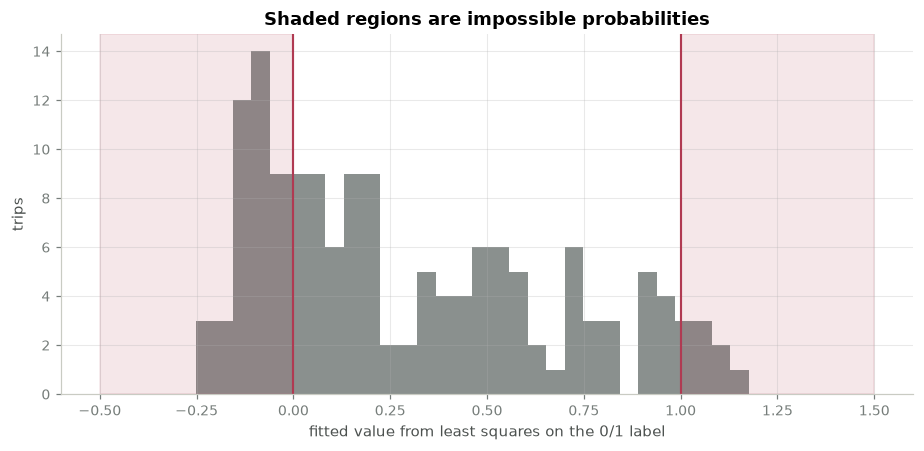

In [4]:
# Least squares on a 0/1 label will leave [0, 1].
w_bad = np.linalg.solve(Ztr.T @ Ztr, Ztr.T @ (ytr - ytr.mean()))
pred_bad = Ztr @ w_bad + ytr.mean()
outside = int(((pred_bad < 0) | (pred_bad > 1)).sum())
print(f'OLS on the 0/1 label predicts outside [0,1] for {outside} of {len(ytr)} trips')
print(f'  range: {pred_bad.min():.2f} to {pred_bad.max():.2f}')

fig, ax = plt.subplots(figsize=(8.5, 4.2))
ax.hist(pred_bad, bins=30, color=C['ols'], alpha=.85)
ax.axvspan(min(-0.5, pred_bad.min()-.1), 0, color=C['rose'], alpha=.12)
ax.axvspan(1, max(1.5, pred_bad.max()+.1), color=C['rose'], alpha=.12)
ax.axvline(0, color=C['rose'], lw=1.4); ax.axvline(1, color=C['rose'], lw=1.4)
ax.set(xlabel='fitted value from least squares on the 0/1 label', ylabel='trips',
       title='Shaded regions are impossible probabilities')
plt.tight_layout(); plt.show()

> **Write-up prompt (6a step 3).** The Bernoulli log-likelihood is
> $\sum_i [y_i \log p_i + (1-y_i)\log(1-p_i)]$ with $p_i = \sigma(x_i^\top w + b)$.
> Maximising it is minimising the average of its negative, which is the log-loss. Same
> manoeuvre as Task 1 with a different density: the loss comes from the noise model.

## 6b — Implement penalized logistic regression

With the intercept **unpenalized**:

$$\frac{1}{n}\sum_i \big[-y_i\log p_i-(1-y_i)\log(1-p_i)\big]
 + \alpha\rho\lVert w\rVert_1 + \frac{\alpha(1-\rho)}{2}\lVert w\rVert_2^2$$

There is no closed form. This is proximal gradient descent with FISTA acceleration: a
gradient step on the smooth part, then the same soft-threshold as Task 3.

In [5]:
def sigmoid(z):
    out = np.empty_like(np.asarray(z, dtype=float))
    z = np.asarray(z, dtype=float)
    pos = z >= 0
    out[pos] = 1 / (1 + np.exp(-z[pos]))
    ez = np.exp(z[~pos])
    out[~pos] = ez / (1 + ez)
    return out


def log_loss(y, p, eps=1e-12):
    p = np.clip(p, eps, 1 - eps)
    return float(-np.mean(y * np.log(p) + (1 - y) * np.log(1 - p)))


def soft_threshold(rho, gamma):
    return np.sign(rho) * np.maximum(np.abs(rho) - gamma, 0.0)


def logistic_fit(Z, y, alpha=0.0, l1_ratio=0.0, max_iter=4000, tol=1e-10):
    # Proximal gradient + FISTA. Returns (w, b, iterations).
    n, p = Z.shape
    l1, l2 = alpha * l1_ratio, alpha * (1 - l1_ratio)
    # step from the Lipschitz constant: |sigma''| <= 1/4, and +1 for the intercept
    L = 0.25 * np.max((Z ** 2).sum(1) + 1) + l2 + 1e-9
    step = 1 / L

    w = np.zeros(p); b = 0.0
    wy, by, tk = w.copy(), b, 1.0

    def obj(ww, bb):
        pr = sigmoid(Z @ ww + bb)
        return log_loss(y, pr) + l1 * np.abs(ww).sum() + l2 / 2 * (ww ** 2).sum()

    prev = obj(w, b)
    for it in range(max_iter):
        d = sigmoid(Z @ wy + by) - y
        g = Z.T @ d / n + l2 * wy
        gb = d.mean()
        w_new = soft_threshold(wy - step * g, step * l1)
        b_new = by - step * gb
        t_next = (1 + np.sqrt(1 + 4 * tk * tk)) / 2
        mom = (tk - 1) / t_next
        wy = w_new + mom * (w_new - w)
        by = b_new + mom * (b_new - b)
        w, b, tk = w_new, b_new, t_next
        if it % 10 == 9:
            cur = obj(w, b)
            if abs(prev - cur) < tol * max(1.0, abs(prev)):
                return w, b, it + 1
            if cur > prev:                 # momentum overshot: restart it
                wy, by, tk = w.copy(), b, 1.0
            prev = cur
    return w, b, max_iter


w_log, b_log, iters = logistic_fit(Ztr, ytr, alpha=0.01, l1_ratio=0.0)
print(f'converged in {iters} iterations,  intercept {b_log:+.4f}')
print(pd.Series({SHORT[f]: round(float(v), 3) for f, v in zip(FEATS, w_log)},
                name='log-odds per s.d.').to_string())

converged in 420 iterations,  intercept -2.3756
is_peak           0.954
is_rain           0.521
traffic_speed    -2.061
drivers_avail    -0.300
is_event          0.567
is_airport        0.701
is_weekend       -0.019
open_requests     0.751
is_bad_weather    0.244


### Verify against scikit-learn

With this objective `LogisticRegression` matches at $C = 1/(n\alpha)$.

> **Read this before you spend an hour debugging.** `solver='liblinear'` **penalizes the
> intercept** and our objective does not, so it disagrees by far more than solver
> tolerance and no tuning will close the gap. Use `lbfgs` for ℓ₂ or `saga` for ℓ₁ and
> elastic net. Setting `intercept_scaling` very large makes liblinear agree, which is how
> you confirm that is the cause.

In [6]:
import warnings
warnings.filterwarnings('ignore')
from sklearn.linear_model import LogisticRegression

n = len(ytr)
print(f"{'alpha':>7} {'rho':>5} {'max|w diff|':>13} {'|b diff|':>10}  solver")
for alpha, rho in [(0.01, 0.0), (0.1, 0.0), (0.02, 1.0), (0.05, 0.5)]:
    mine_w, mine_b, _ = logistic_fit(Ztr, ytr, alpha, rho, max_iter=80000, tol=1e-14)
    Cpar = 1.0 / (n * alpha)
    if rho == 0.0:
        sk = LogisticRegression(C=Cpar, solver='lbfgs', max_iter=50000, tol=1e-12)
        name = 'lbfgs'
    else:
        sk = LogisticRegression(C=Cpar, penalty='elasticnet', l1_ratio=rho,
                                solver='saga', max_iter=500000, tol=1e-12)
        name = 'saga'
    sk.fit(Ztr, ytr)
    dw = float(np.max(np.abs(mine_w - sk.coef_[0])))
    db = float(abs(mine_b - sk.intercept_[0]))
    print(f'{alpha:>7} {rho:>5} {dw:>13.2e} {db:>10.2e}  {name}')

lib = LogisticRegression(C=1/(n*0.02), penalty='l1', solver='liblinear',
                         max_iter=50000, tol=1e-12).fit(Ztr, ytr)
lib2 = LogisticRegression(C=1/(n*0.02), penalty='l1', solver='liblinear',
                          intercept_scaling=1e4, max_iter=50000, tol=1e-12).fit(Ztr, ytr)
mine_w, mine_b, _ = logistic_fit(Ztr, ytr, 0.02, 1.0, max_iter=80000, tol=1e-14)
print()
print(f'liblinear default      b = {lib.intercept_[0]:+.4f}   <- intercept penalized')
print(f'liblinear scaling=1e4  b = {lib2.intercept_[0]:+.4f}')
print(f'ours                   b = {mine_b:+.4f}   <- matches the rescaled version')

  alpha   rho   max|w diff|   |b diff|  solver
   0.01   0.0      4.40e-07   2.15e-07  lbfgs
    0.1   0.0      2.05e-07   7.10e-07  lbfgs
   0.02   1.0      2.75e-07   8.68e-08  saga
   0.05   0.5      8.01e-07   8.73e-07  saga

liblinear default      b = -1.6369   <- intercept penalized
liblinear scaling=1e4  b = -2.0793
ours                   b = -2.0793   <- matches the rescaled version


## 6c — Coefficient paths and the elimination order

findfont: Failed to find font weight 600 for DejaVu Sans, now using 700.


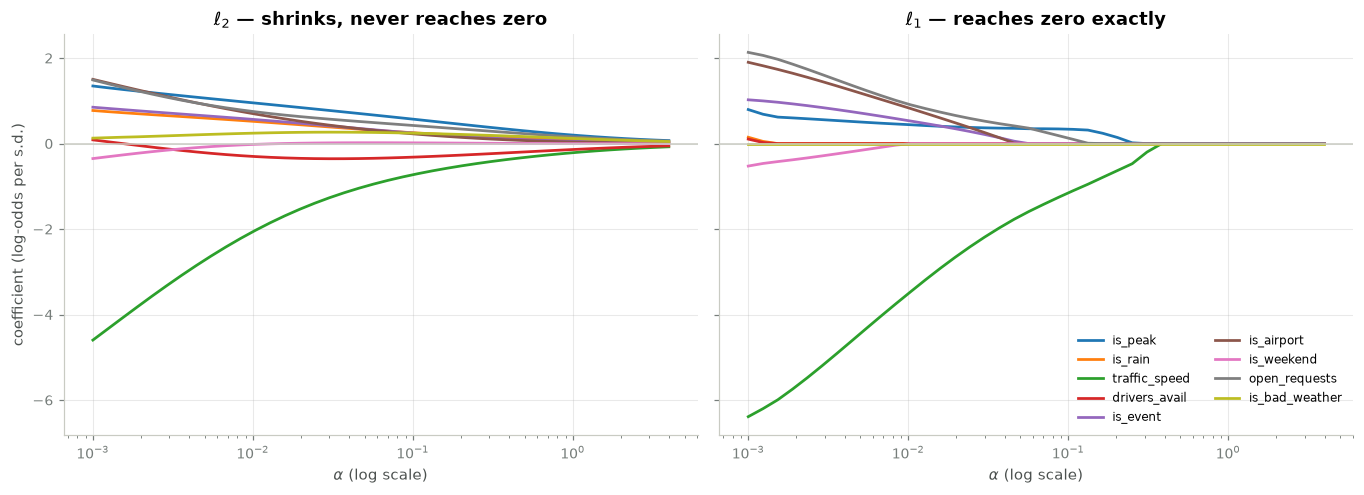

l1 elimination order (feature, alpha at which it died):
  is_bad_weather   0.001
  is_rain          0.0015
  drivers_avail    0.0015
  is_weekend       0.0104
  is_event         0.0567
  is_airport       0.0567
  open_requests    0.1642
  is_peak          0.3107
  traffic_speed    0.3843


In [7]:
alphas = np.logspace(-3, 0.6, 40)
paths = {rho: np.array([logistic_fit(Ztr, ytr, a, rho)[0] for a in alphas])
         for rho in (0.0, 1.0)}

fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.6), sharey=True)
titles = ['$\\ell_2$ — shrinks, never reaches zero', '$\\ell_1$ — reaches zero exactly']
for ax, rho, title in zip(axes, (0.0, 1.0), titles):
    for j, f in enumerate(FEATS):
        ax.plot(alphas, paths[rho][:, j], lw=1.8, label=SHORT[f])
    ax.set_xscale('log'); ax.axhline(0, color='#c9cbc3', lw=1)
    ax.set(xlabel=r'$\alpha$ (log scale)', title=title)
axes[0].set_ylabel('coefficient (log-odds per s.d.)')
axes[1].legend(ncol=2, fontsize=8)
plt.tight_layout(); plt.show()

order, seen = [], set()
for k, a in enumerate(alphas):
    for j in np.where(np.abs(paths[1.0][k]) < 1e-8)[0]:
        if j not in seen:
            seen.add(j); order.append((SHORT[FEATS[j]], round(float(a), 4)))
print('l1 elimination order (feature, alpha at which it died):')
for f, a in order:
    print(f'  {f:<16} {a}')

> **Write-up prompt (6c step 2).** Compare this with your Task 3c prediction. On this data
> the redundant weather features tend to go *before* `is_weekend`, even though
> `is_weekend` has no real effect at all — because `traffic_speed` already carries the
> weather information and ℓ₁ will not pay for it twice.
>
> So an ℓ₁ ordering ranks **marginal usefulness given the other features**, not true
> importance. That is the selection-instability caveat from Theory §5.3 in a new guise,
> and a good reason not to read a Lasso's survivors as a causal story.

In [8]:
def cv_log_loss(Z, y, k, fit):
    n = len(y); idx = np.arange(n); tot = cnt = 0.0
    for f in range(k):
        te = np.zeros(n, bool); te[idx[f::k]] = True
        w, b, _ = fit(Z[~te], y[~te])
        p = sigmoid(Z[te] @ w + b)
        tot += log_loss(y[te], p) * te.sum(); cnt += te.sum()
    return tot / cnt


def auc(y, score):
    order = np.argsort(score, kind='mergesort')
    ranks = np.empty(len(score), float); i = 0
    while i < len(order):
        j = i
        while j + 1 < len(order) and score[order[j+1]] == score[order[i]]:
            j += 1
        ranks[order[i:j+1]] = (i + j) / 2 + 1
        i = j + 1
    P, N = int(y.sum()), int((1 - y).sum())
    return float((ranks[y == 1].sum() - P * (P + 1) / 2) / (P * N))


grid = np.logspace(-3, 0.3, 22)
rows = []
for name, rho in [('no penalty', None), ('l2', 0.0), ('l1', 1.0), ('elastic', 0.5)]:
    if rho is None:
        alpha, rr = 1e-6, 0.0
    else:
        rr = rho
        scores = [cv_log_loss(Ztr, ytr, 5, lambda Z, t, a=a: logistic_fit(Z, t, a, rr))
                  for a in grid]
        alpha = float(grid[int(np.argmin(scores))])
    w, b, _ = logistic_fit(Ztr, ytr, alpha, rr)
    p = sigmoid(Zte @ w + b)
    rows.append({'model': name, 'alpha': None if rho is None else round(alpha, 5),
                 'test_logloss': round(log_loss(yte, p), 4),
                 'test_auc': round(auc(yte, p), 4),
                 'test_acc': round(float(((p >= .5).astype(int) == yte).mean()), 4),
                 'non_zero': int((np.abs(w) > 1e-8).sum()),
                 'dropped': ', '.join(SHORT[f] for f, v in zip(FEATS, w)
                                      if abs(v) < 1e-8) or '-'})
cls_table = pd.DataFrame(rows)
print(cls_table.to_string(index=False))
print()
print(f'base rate on the test split: {max(yte.mean(), 1-yte.mean()):.1%}')

     model   alpha  test_logloss  test_auc  test_acc  non_zero                                            dropped
no penalty     NaN        0.2887    0.9779      0.90         9                                                  -
        l2 0.00425        0.1698    0.9798      0.92         9                                                  -
        l1 0.01259        0.2117    0.9706      0.88         5 is_rain, drivers_avail, is_weekend, is_bad_weather
   elastic 0.00877        0.1748    0.9798      0.92         7                         is_weekend, is_bad_weather

base rate on the test split: 68.0%


## 6d — ROC, and choosing a threshold

best by CV log-loss: l2 (alpha=0.00425)

 thresh   TP   FP   TN   FN   recall  precision    cost
   0.05   16    6   28    0    1.000      0.727       6
   0.10   16    5   29    0    1.000      0.762       5
   0.15   15    5   29    1    0.938      0.750       9
   0.20   15    4   30    1    0.938      0.789       8
   0.25   14    3   31    2    0.875      0.824      11
   0.30   14    3   31    2    0.875      0.824      11
   0.35   14    2   32    2    0.875      0.875      10
   0.40   14    1   33    2    0.875      0.933       9
   0.45   14    1   33    2    0.875      0.933       9
   0.50   13    1   33    3    0.812      0.929      13
   0.55   13    1   33    3    0.812      0.929      13
   0.60   12    1   33    4    0.750      0.923      17
   0.65   11    1   33    5    0.688      0.917      21
   0.70   11    1   33    5    0.688      0.917      21
   0.75   11    1   33    5    0.688      0.917      21
   0.80   11    1   33    5    0.688      0.917      21
   0.85

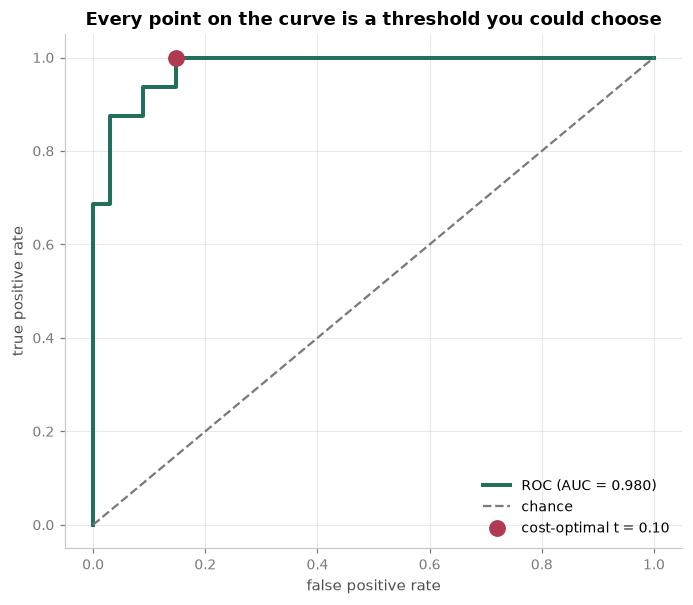

In [9]:
best = cls_table.loc[cls_table.test_logloss.idxmin()]
rho_best = {'no penalty': 0.0, 'l2': 0.0, 'l1': 1.0, 'elastic': 0.5}[best.model]
w_b, b_b, _ = logistic_fit(Ztr, ytr, best.alpha if best.alpha else 1e-6, rho_best)
p_te = sigmoid(Zte @ w_b + b_b)
print(f'best by CV log-loss: {best.model} (alpha={best.alpha})')


def confusion(y, p, t):
    hat = (p >= t).astype(int)
    return (int(((hat == 1) & (y == 1)).sum()), int(((hat == 1) & (y == 0)).sum()),
            int(((hat == 0) & (y == 0)).sum()), int(((hat == 0) & (y == 1)).sum()))


MISS_COST, FALSE_COST = 4, 1     # dispatch: a missed alert costs 4x a false alarm
print()
print(f"{'thresh':>7}{'TP':>5}{'FP':>5}{'TN':>5}{'FN':>5}{'recall':>9}{'precision':>11}{'cost':>8}")
best_t, best_cost = None, np.inf
for t in np.arange(0.05, 0.96, 0.05):
    tp, fp, tn, fn = confusion(yte, p_te, t)
    cost = MISS_COST * fn + FALSE_COST * fp
    if cost < best_cost:
        best_cost, best_t = cost, t
    rec = tp / (tp + fn) if tp + fn else float('nan')
    prec = tp / (tp + fp) if tp + fp else float('nan')
    print(f'{t:>7.2f}{tp:>5}{fp:>5}{tn:>5}{fn:>5}{rec:>9.3f}{prec:>11.3f}{cost:>8}')
print()
print(f'minimum expected cost at threshold {best_t:.2f}  (cost {best_cost})')
print('Note it is BELOW 0.5: when a miss costs 4x a false alarm, alert more readily.')

fpr, tpr = [], []
for t in np.r_[1.01, np.sort(p_te)[::-1], -0.01]:
    tp, fp, tn, fn = confusion(yte, p_te, t)
    tpr.append(tp / (tp + fn) if tp + fn else 0.0)
    fpr.append(fp / (fp + tn) if fp + tn else 0.0)

fig, ax = plt.subplots(figsize=(6.4, 5.6))
ax.plot(fpr, tpr, lw=2.6, color=C['accent'], label=f'ROC (AUC = {auc(yte, p_te):.3f})')
ax.plot([0, 1], [0, 1], '--', color=C['ols'], label='chance')
tp, fp, tn, fn = confusion(yte, p_te, best_t)
ax.plot(fp / (fp + tn), tp / (tp + fn), 'o', ms=10, color=C['rose'],
        label=f'cost-optimal t = {best_t:.2f}')
ax.set(xlabel='false positive rate', ylabel='true positive rate',
       title='Every point on the curve is a threshold you could choose')
ax.legend(loc='lower right')
plt.tight_layout(); plt.show()

> **Write-up prompt (6d step 3).** The cost-minimising threshold is below 0.5, because a
> missed alert is four times as expensive as a false alarm. Note what did **not** change
> when you moved it: not a single coefficient. The threshold is a policy parameter and
> belongs beside the ₹150 cap from Task 5, not inside the model.

## 6e — Was the label worth making?

In [10]:
def ridge_norm(Z, y, a):
    n_, p_ = Z.shape
    return np.linalg.solve(Z.T @ Z + n_ * a * np.eye(p_), Z.T @ y)


def kfold_rmse(Z, y, k, fit):
    # k-fold CV on the CONTINUOUS target; re-centre y inside each fold.
    n_ = len(y); idx = np.arange(n_); tot = 0.0
    for f in range(k):
        te = np.zeros(n_, bool); te[idx[f::k]] = True
        ybar = y[~te].mean()
        w = fit(Z[~te], y[~te] - ybar)
        tot += float(np.sum((y[te] - (Z[te] @ w + ybar)) ** 2))
    return float(np.sqrt(tot / n_))


grid_lin = np.logspace(-3, 1.7, 24)
cv = [kfold_rmse(Ztr, ytr_rupees, 5, lambda Z, t, a=a: ridge_norm(Z, t, a))
      for a in grid_lin]
a_lin = float(grid_lin[int(np.argmin(cv))])
w_lin = ridge_norm(Ztr, ytr_rupees - ytr_rupees.mean(), a_lin)
yhat_rupees = Zte @ w_lin + ytr_rupees.mean()
hard = (yhat_rupees > CUT).astype(int)

cls_acc = float(((p_te >= 0.5).astype(int) == yte).mean())
cls_auc = auc(yte, p_te)
lin_acc = float((hard == yte).mean())
lin_auc = auc(yte, yhat_rupees)

print(f'{"":<36}{"accuracy":>10}{"AUC":>8}')
print(f'{"purpose-built classifier":<36}{cls_acc:>10.3f}{cls_auc:>8.3f}')
print(f'{"Ridge in rupees, then cut at " + str(int(CUT)):<36}{lin_acc:>10.3f}{lin_auc:>8.3f}')
print()
print(f'base rate: {max(yte.mean(), 1-yte.mean()):.3f}')
print()
if lin_auc >= cls_auc - 0.005:
    print('The regression matches or beats the classifier, and it also tells you HOW FAR')
    print('above the cut each cell sits, which the classifier discarded. Dichotomising the')
    print('target cost resolution and bought nothing.')
else:
    print('The classifier wins here. Say what it exploits that the regression does not.')

                                      accuracy     AUC
purpose-built classifier                 0.920   0.980
Ridge in rupees, then cut at 100         0.940   0.989

base rate: 0.680

The regression matches or beats the classifier, and it also tells you HOW FAR
above the cut each cell sits, which the classifier discarded. Dichotomising the
target cost resolution and bought nothing.


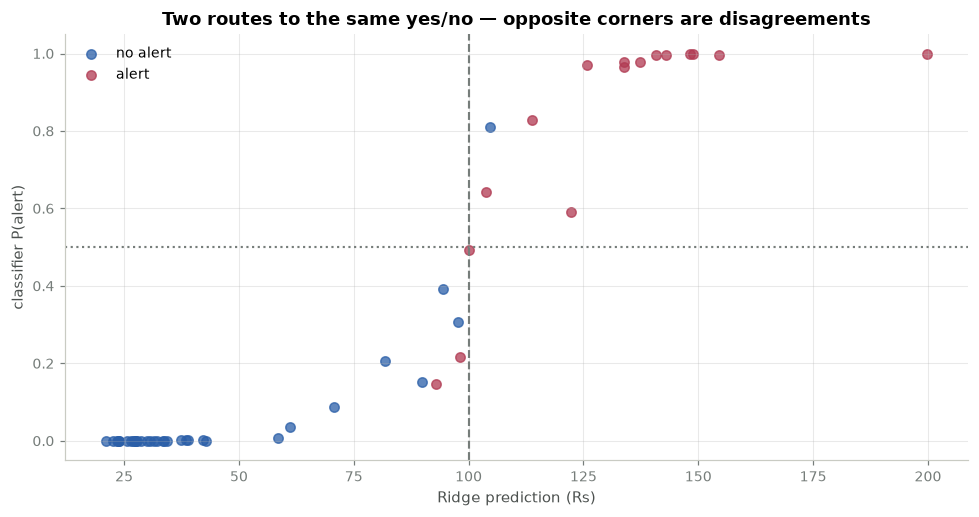

the two approaches disagree on 1 of 50 held-out trips


In [11]:
fig, ax = plt.subplots(figsize=(9, 4.8))
ok = yte == 1
ax.scatter(yhat_rupees[~ok], p_te[~ok], s=38, color=C['ridge'], alpha=.75, label='no alert')
ax.scatter(yhat_rupees[ok], p_te[ok], s=38, color=C['rose'], alpha=.75, label='alert')
ax.axvline(CUT, color=C['ols'], ls='--', lw=1.4)
ax.axhline(0.5, color=C['ols'], ls=':', lw=1.4)
ax.set(xlabel='Ridge prediction (Rs)', ylabel='classifier P(alert)',
       title='Two routes to the same yes/no — opposite corners are disagreements')
ax.legend()
plt.tight_layout(); plt.show()

dis = int(((yhat_rupees > CUT) != (p_te >= 0.5)).sum())
print(f'the two approaches disagree on {dis} of {len(yte)} held-out trips')

---

### Checklist

- [ ] Base rate quoted beside every accuracy
- [ ] OLS-on-0/1 shown leaving [0, 1], with a reason
- [ ] `logistic_fit` written from scratch, matching sklearn via **lbfgs / saga**
- [ ] The liblinear intercept trap identified
- [ ] Coefficient paths for ℓ₂ and ℓ₁; elimination order vs your Task 3c guess
- [ ] Model selection on **log-loss**, not accuracy
- [ ] ROC, AUC, and a threshold justified by the 4:1 cost ratio (**Deliverable 4**)
- [ ] 6e answered: did dichotomising the target cost anything?

Nothing in Task 6 needed a new idea about priors — only a new likelihood.